# 🏥 TRUSTformer Phase 3: Medical Ultrasound Classification
### Breast Ultrasound Images Dataset (BUSI) — Google Colab (GPU)

**Author:** Harsh Pratap Sinha | SAP: S00123860 | Batch-04

---

## What is New in Phase 3

| Dimension | Phase 2 (MNIST) | Phase 3 (BUSI) |
|---|---|---|
| Dataset | Grayscale digits, 10 classes | RGB medical ultrasound, **3 classes** |
| Classes | 0–9 digits | `normal` / `benign` / `malignant` |
| Image size | 28×28 | **224×224** (resized) |
| Input channels | 1 | **3 (RGB)** |
| Samples | 70,000 | ~780 images (small medical dataset) |
| Class balance | Near-uniform | **Severely imbalanced** (requires WeightedSampler + weighted loss) |
| Stability Gap expected | Weak (~0.001) | **Stronger** — harder task, higher error rate, larger trust signal separation |
| Patch config | 4×4 → 49 patches | **16×16 → 196 patches** |
| Embed dim | 64 | **128** |
| Encoder layers | 2 | **4** |
| Heads | 4 | **8** |

## Architecture Overview

```
Ultrasound Image (224×224×3)
         ↓
  Patch Embedding  (16×16 patches → 196 patches + [CLS] token)
         ↓
  Positional Embedding (learnable, 197 × 128)
         ↓
  ┌────────────────────────────────────────────┐
  │       TRUSTformer ENCODER ×4               │
  │                                            │
  │   Stability-Aware Self-Attention (8 heads) │  ← Attention Entropy
  │              ↓                             │
  │   Self-Consistency Layer                   │  ← Noise perturbation → L2 dist
  │              ↓                             │
  │           FFNN (GELU, Dropout)             │
  └────────────────────────────────────────────┘
         ↓
  ┌──────────────┐     ┌──────────────┐
  │  Class Head  │     │  Trust Head  │  ← Confidence score (0–1)
  │  (3 logits)  │     │  (1 scalar)  │
  └──────────────┘     └──────────────┘
         ↓                     ↓
  Weighted CrossEntropy    Stability Gap Analysis
  (handles class imbalance)
```

**Key evaluation metric:** Stability Gap = `trust_when_correct − trust_when_wrong`  
On BUSI (~25–30% error rate), this gap is expected to be far more pronounced than MNIST.


## ⚙️ Cell 1 — Environment Setup & GPU Check

In [1]:
# Verify GPU — Runtime > Change runtime type > GPU (T4) if not detected
import subprocess, sys

def check_gpu():
    try:
        result = subprocess.run(
            ['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
            capture_output=True, text=True
        )
        print("✅ GPU detected:", result.stdout.strip())
    except Exception:
        print("⚠️  No GPU found. Go to Runtime → Change runtime type → GPU")

check_gpu()

import torch
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

✅ GPU detected: Tesla T4, 15360 MiB
PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4
VRAM            : 15.6 GB


## 📦 Cell 2 — Install kagglehub & Imports

In [2]:
# Install kagglehub (pre-installed in newer Colab, but install explicitly to be safe)
!pip install -q kagglehub

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
import torchvision.transforms as T
from torchvision.transforms import InterpolationMode

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import os, glob, collections, warnings
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

warnings.filterwarnings("ignore")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on: {DEVICE.upper()}")

Running on: CUDA


## 🔧 Cell 3 — Configuration

Scaled up from Phase 2: 224×224 images, 16×16 patches (196 patches), `embed_dim=128`, 4 encoder layers, 8 heads.

In [3]:
class Config:
    # ── Data
    img_size      = 224             # BUSI images resized to 224×224
    patch_size    = 16              # 224 / 16 = 14  →  14×14 = 196 patches
    num_patches   = (img_size // patch_size) ** 2   # 196
    in_channels   = 3              # RGB ultrasound images
    num_classes   = 3              # normal / benign / malignant
    batch_size    = 32             # small dataset — keep batch size manageable
    val_split     = 0.15
    test_split    = 0.15
    # ── Model (scaled up from Phase 2)
    embed_dim     = 128
    num_heads     = 8
    num_layers    = 4
    ffn_dim       = 256
    dropout       = 0.1
    # ── Self-Consistency
    noise_std     = 0.05
    # ── Training
    epochs        = 30             # more epochs needed — small dataset, harder task
    lr            = 1e-4           # lower LR than MNIST; less data, more complex
    weight_decay  = 1e-4
    device        = DEVICE
    seed          = 42

cfg = Config()

# Reproducibility
torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)

print(f"Image size       : {cfg.img_size}×{cfg.img_size}×{cfg.in_channels}")
print(f"Patch size       : {cfg.patch_size}×{cfg.patch_size}")
print(f"Num patches      : {cfg.num_patches}  (+1 CLS = {cfg.num_patches+1} tokens)")
print(f"Embed dim        : {cfg.embed_dim}")
print(f"Encoder layers   : {cfg.num_layers}")
print(f"Num heads        : {cfg.num_heads}")
print(f"Num classes      : {cfg.num_classes}  (normal / benign / malignant)")
print(f"Batch size       : {cfg.batch_size}")
print(f"Epochs           : {cfg.epochs}")

Image size       : 224×224×3
Patch size       : 16×16
Num patches      : 196  (+1 CLS = 197 tokens)
Embed dim        : 128
Encoder layers   : 4
Num heads        : 8
Num classes      : 3  (normal / benign / malignant)
Batch size       : 32
Epochs           : 30


## 📥 Cell 4 — Download BUSI Dataset via kagglehub

Downloads the **Breast Ultrasound Images Dataset** by Arya Shah from Kaggle.  
Classes: `benign/`, `malignant/`, `normal/` — each folder contains ultrasound images + mask images.  
We filter out `_mask` files to use only the original images.

In [4]:
import kagglehub

# Download latest version of the BUSI dataset
path = kagglehub.dataset_download("aryashah2k/breast-ultrasound-images-dataset")
print(f"Dataset downloaded to: {path}")

# Explore directory structure
print("\nDirectory structure:")
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 2 * level
    if level <= 2:
        print(f'{indent}{os.path.basename(root)}/')
        if level == 1:
            # Count non-mask images per class folder
            imgs = [f for f in files if not '_mask' in f and f.endswith(('.png', '.jpg', '.jpeg'))]
            print(f'{indent}  → {len(imgs)} images (excl. masks)')

DATASET_ROOT = path
CLASS_NAMES  = ['benign', 'malignant', 'normal']
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
print(f"\nClass mapping: {CLASS_TO_IDX}")

Using Colab cache for faster access to the 'breast-ultrasound-images-dataset' dataset.
Dataset downloaded to: /kaggle/input/breast-ultrasound-images-dataset

Directory structure:
breast-ultrasound-images-dataset/
  Dataset_BUSI_with_GT/
    → 0 images (excl. masks)
    benign/
    normal/
    malignant/

Class mapping: {'benign': 0, 'malignant': 1, 'normal': 2}


## 🗂️ Cell 5 — Build File Lists & Analyse Class Distribution

BUSI is **imbalanced**: benign (~437) >> malignant (~210) >> normal (~133).  
We handle this with: `WeightedRandomSampler` (training) + `class_weight` in CrossEntropy loss.

Total images (excl. masks): 780

Class distribution:
  [0] benign       :  437 images (56.0%)
  [1] malignant    :  210 images (26.9%)
  [2] normal       :  133 images (17.1%)


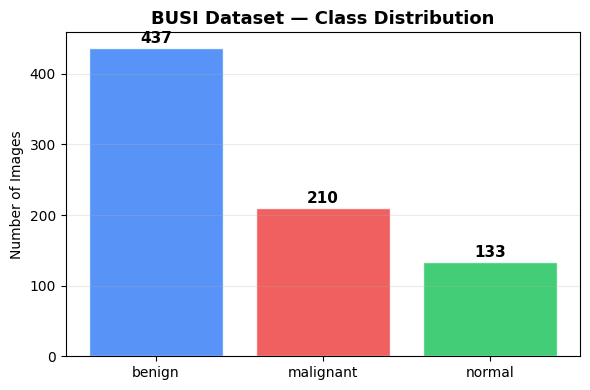

In [5]:
def collect_image_paths(root, class_names):
    """
    Walk each class folder, collect non-mask .png/.jpg paths.
    Returns: list of (filepath, label_int) tuples.
    """
    samples = []
    for cls_name in class_names:
        cls_dir = os.path.join(root, cls_name)
        # Handle nested structure if dataset has extra subdirectory
        if not os.path.isdir(cls_dir):
            for sub in os.listdir(root):
                candidate = os.path.join(root, sub, cls_name)
                if os.path.isdir(candidate):
                    cls_dir = candidate
                    break
        label = CLASS_TO_IDX[cls_name]
        for ext in ['*.png', '*.jpg', '*.jpeg', '*.PNG', '*.JPG']:
            for fpath in glob.glob(os.path.join(cls_dir, ext)):
                if '_mask' not in os.path.basename(fpath):
                    samples.append((fpath, label))
    return samples

all_samples = collect_image_paths(DATASET_ROOT, CLASS_NAMES)
print(f"Total images (excl. masks): {len(all_samples)}")

# Class distribution
from collections import Counter
label_counts = Counter(lbl for _, lbl in all_samples)
print("\nClass distribution:")
for cls_name, idx in CLASS_TO_IDX.items():
    print(f"  [{idx}] {cls_name:<12} : {label_counts[idx]:>4} images ({label_counts[idx]/len(all_samples)*100:.1f}%)")

# Visualise class distribution
fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#3b82f6', '#ef4444', '#22c55e']
bars = ax.bar(CLASS_NAMES, [label_counts[i] for i in range(3)], color=colors, alpha=0.85, edgecolor='white')
for b, v in zip(bars, [label_counts[i] for i in range(3)]):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 3, str(v),
            ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_title("BUSI Dataset — Class Distribution", fontweight='bold', fontsize=13)
ax.set_ylabel("Number of Images")
ax.grid(alpha=0.25, axis='y')
plt.tight_layout()
plt.savefig("busi_class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

## 🖼️ Cell 6 — BUSI Dataset Class & Data Augmentation

Medical imaging augmentation strategy:
- **Train**: RandomHorizontalFlip, RandomRotation(±15°), ColorJitter, RandomAffine — keeps clinically plausible distortions
- **Val/Test**: CenterCrop only — no augmentation to get clean evaluation

In [6]:
# ImageNet mean/std — appropriate for RGB medical images with pretrain-style normalisation
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((cfg.img_size, cfg.img_size), interpolation=InterpolationMode.BILINEAR),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = T.Compose([
    T.Resize((cfg.img_size, cfg.img_size), interpolation=InterpolationMode.BILINEAR),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class BUSIDataset(Dataset):
    """
    PyTorch Dataset for the Breast Ultrasound Images Dataset.
    Loads images on-the-fly from file paths.
    """
    def __init__(self, samples, transform=None):
        """
        Args:
            samples   : list of (filepath, label_int) tuples
            transform : torchvision transforms to apply
        """
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fpath, label = self.samples[idx]
        img = Image.open(fpath).convert('RGB')   # force RGB even if greyscale TIFF
        if self.transform:
            img = self.transform(img)
        return img, label

print("BUSIDataset class defined ✓")
print(f"Train transforms : {len(train_transform.transforms)} steps")
print(f"Val  transforms  : {len(val_transform.transforms)} steps")

BUSIDataset class defined ✓
Train transforms : 7 steps
Val  transforms  : 3 steps


## 🔀 Cell 7 — Stratified Train / Val / Test Split + WeightedRandomSampler

In [7]:
from sklearn.model_selection import train_test_split

filepaths = [s[0] for s in all_samples]
labels    = [s[1] for s in all_samples]

# Stratified split: 70% train, 15% val, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    filepaths, labels, test_size=cfg.test_split, stratify=labels, random_state=cfg.seed
)
val_frac_of_temp = cfg.val_split / (1 - cfg.test_split)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_frac_of_temp, stratify=y_temp, random_state=cfg.seed
)

train_samples = list(zip(X_train, y_train))
val_samples   = list(zip(X_val,   y_val))
test_samples  = list(zip(X_test,  y_test))

print(f"Train : {len(train_samples):4d} samples")
print(f"Val   : {len(val_samples):4d} samples")
print(f"Test  : {len(test_samples):4d} samples")

# ── WeightedRandomSampler for training (handles class imbalance)
train_label_counts = Counter(y_train)
class_weights_inv  = {cls: 1.0 / count for cls, count in train_label_counts.items()}
sample_weights     = [class_weights_inv[lbl] for lbl in y_train]
sampler = WeightedRandomSampler(
    weights=sample_weights, num_samples=len(sample_weights), replacement=True
)

# ── Class weights for CrossEntropy loss (inverse frequency)
total_train = len(y_train)
ce_weights  = torch.tensor(
    [total_train / (cfg.num_classes * train_label_counts[i]) for i in range(cfg.num_classes)],
    dtype=torch.float32
).to(cfg.device)
print(f"\nCE Loss class weights: {ce_weights.tolist()}")
print("(Higher weight = rarer class penalised more when misclassified)")

# ── DataLoaders
train_ds = BUSIDataset(train_samples, transform=train_transform)
val_ds   = BUSIDataset(val_samples,   transform=val_transform)
test_ds  = BUSIDataset(test_samples,  transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, sampler=sampler,
                           num_workers=2, pin_memory=(cfg.device=="cuda"))
val_loader   = DataLoader(val_ds,   batch_size=cfg.batch_size, shuffle=False,
                           num_workers=2, pin_memory=(cfg.device=="cuda"))
test_loader  = DataLoader(test_ds,  batch_size=cfg.batch_size, shuffle=False,
                           num_workers=2, pin_memory=(cfg.device=="cuda"))

print(f"\nTrain batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

Train :  545 samples
Val   :  118 samples
Test  :  117 samples

CE Loss class weights: [0.5956284403800964, 1.2358276844024658, 1.9534050226211548]
(Higher weight = rarer class penalised more when misclassified)

Train batches : 18
Val batches   : 4
Test batches  : 4


## 🖼️ Cell 8 — Visualise Sample Ultrasound Images

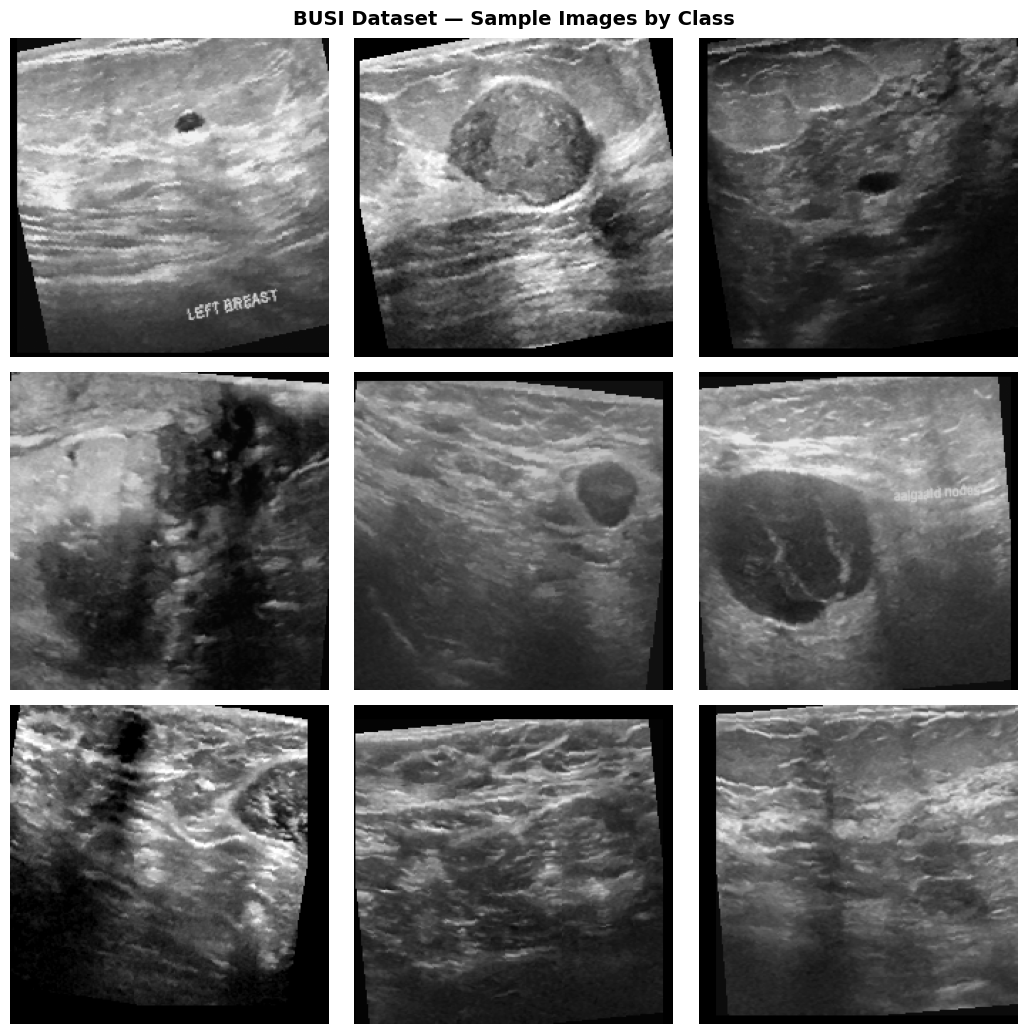

In [8]:
def show_busi_samples(dataset, class_names, n_per_class=3):
    """
    Shows n_per_class images for each class in the dataset.
    Un-normalises for display using ImageNet mean/std.
    """
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    # Collect indices per class
    class_indices = {i: [] for i in range(len(class_names))}
    for idx, (_, lbl) in enumerate(dataset.samples):
        if len(class_indices[lbl]) < n_per_class:
            class_indices[lbl].append(idx)

    fig, axes = plt.subplots(len(class_names), n_per_class,
                              figsize=(n_per_class * 3.5, len(class_names) * 3.5))
    fig.suptitle("BUSI Dataset — Sample Images by Class", fontsize=14, fontweight='bold')

    colors = ['#3b82f6', '#ef4444', '#22c55e']
    for row, cls_idx in enumerate(range(len(class_names))):
        for col, img_idx in enumerate(class_indices[cls_idx]):
            img, lbl = dataset[img_idx]
            img_display = img * std + mean           # un-normalise
            img_display = img_display.permute(1, 2, 0).clamp(0, 1).numpy()
            ax = axes[row, col]
            ax.imshow(img_display)
            if col == 0:
                ax.set_ylabel(class_names[cls_idx].upper(),
                              fontsize=11, fontweight='bold',
                              color=colors[cls_idx], rotation=90, labelpad=10)
            ax.axis('off')

    plt.tight_layout()
    plt.savefig("busi_samples.png", dpi=150, bbox_inches='tight')
    plt.show()

show_busi_samples(train_ds, CLASS_NAMES)

## 🧩 Cell 9 — Module 1: Patch Embedding (adapted for 224×224 RGB)

**Change from Phase 2:** `in_channels=3`, `patch_size=16`, `num_patches=196`, `embed_dim=128`.

In [9]:
class PatchEmbedding(nn.Module):
    """
    224×224×3 image → 196 patches (16×16×3=768 dims) → linear project → 128-dim
    Prepends [CLS] token | Adds learnable positional embedding
    Output shape: (B, 197, 128)   [197 = 196 patches + 1 CLS]
    """
    def __init__(self, cfg):
        super().__init__()
        patch_dim         = cfg.in_channels * cfg.patch_size * cfg.patch_size  # 3*16*16=768
        self.projection   = nn.Linear(patch_dim, cfg.embed_dim)
        self.cls_token    = nn.Parameter(torch.randn(1, 1, cfg.embed_dim) * 0.02)
        self.pos_embed    = nn.Parameter(torch.randn(1, cfg.num_patches + 1, cfg.embed_dim) * 0.02)
        self.patch_size   = cfg.patch_size
        self.dropout      = nn.Dropout(cfg.dropout)

    def forward(self, x):
        B, C, H, W = x.shape
        p = self.patch_size
        # Unfold into non-overlapping patches
        x = x.unfold(2, p, p).unfold(3, p, p)       # (B, C, n_h, n_w, p, p)
        x = x.contiguous().view(B, C, -1, p * p)     # (B, C, num_patches, p²)
        x = x.permute(0, 2, 1, 3).contiguous()       # (B, num_patches, C, p²)
        x = x.view(B, -1, C * p * p)                 # (B, num_patches, patch_dim)
        x = self.projection(x)                        # (B, num_patches, embed_dim)
        # Prepend CLS token
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)             # (B, 197, embed_dim)
        x   = x + self.pos_embed
        return self.dropout(x)

# Quick shape test
_pe_test = PatchEmbedding(cfg)(torch.randn(2, 3, 224, 224))
print(f"PatchEmbedding output shape: {_pe_test.shape}")   # expect (2, 197, 128)

PatchEmbedding output shape: torch.Size([2, 197, 128])


## 🔬 Cell 10 — Module 2: Stability-Aware Self-Attention (unchanged mechanism, scaled dims)

Attention entropy formula (unchanged from Phase 2):
```
entropy(i, h, n) = -Σ_j  attn[i, h, n, j] × log( attn[i, h, n, j] + ε )
entropy_score(i) = mean over all heads h and query tokens n
```
Now with `num_heads=8`, `embed_dim=128`, `head_dim=16`.

In [10]:
class StabilityAwareAttention(nn.Module):
    """
    Multi-Head Self-Attention that returns BOTH the output representation
    AND a per-sample attention entropy score.

    entropy shape: (B,)  — one scalar per sample in the batch
    High entropy  → attention spread across many patches → uncertain → unstable
    Low entropy   → attention focused on specific patches → confident → stable
    """
    def __init__(self, cfg):
        super().__init__()
        self.num_heads = cfg.num_heads
        self.head_dim  = cfg.embed_dim // cfg.num_heads      # 128 / 8 = 16
        self.scale     = self.head_dim ** -0.5
        self.qkv       = nn.Linear(cfg.embed_dim, 3 * cfg.embed_dim, bias=False)
        self.proj      = nn.Linear(cfg.embed_dim, cfg.embed_dim)
        self.attn_drop = nn.Dropout(cfg.dropout)
        self.proj_drop = nn.Dropout(cfg.dropout)

    def forward(self, x):
        B, N, D = x.shape
        H = self.num_heads

        # QKV projection and reshape
        qkv = self.qkv(x).reshape(B, N, 3, H, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]           # each: (B, H, N, head_dim)

        # Scaled dot-product attention
        attn = (q @ k.transpose(-2, -1)) * self.scale   # (B, H, N, N)
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        # ── Attention Entropy (per sample, averaged over heads and query tokens)
        #    entropy(i,h,n) = -Σ_j attn[i,h,n,j] * log(attn[i,h,n,j] + ε)
        ent = -(attn * torch.log(attn + 1e-9)).sum(dim=-1)  # (B, H, N)
        entropy = ent.mean(dim=[1, 2])                       # (B,)

        # Standard output: weighted sum of values
        out = (attn @ v).transpose(1, 2).reshape(B, N, D)   # (B, N, D)
        out = self.proj_drop(self.proj(out))

        return out, entropy


# Quick test
_sa  = StabilityAwareAttention(cfg)
_out, _ent = _sa(torch.randn(2, 197, 128))
print(f"Attention output : {_out.shape}")
print(f"Entropy shape    : {_ent.shape}")

Attention output : torch.Size([2, 197, 128])
Entropy shape    : torch.Size([2])


## 🏗️ Cell 11 — Module 3: Stability Encoder Layer (Pre-Norm Transformer Block)

In [11]:
class StabilityEncoderLayer(nn.Module):
    """
    Pre-norm Transformer encoder block with Stability-Aware Attention.
    Returns (output_sequence, attention_entropy).
    """
    def __init__(self, cfg):
        super().__init__()
        self.norm1 = nn.LayerNorm(cfg.embed_dim)
        self.attn  = StabilityAwareAttention(cfg)
        self.norm2 = nn.LayerNorm(cfg.embed_dim)
        self.ffn   = nn.Sequential(
            nn.Linear(cfg.embed_dim, cfg.ffn_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.ffn_dim, cfg.embed_dim),
            nn.Dropout(cfg.dropout),
        )

    def forward(self, x):
        # Pre-norm attention with residual
        normed     = self.norm1(x)
        attn_out, entropy = self.attn(normed)
        x = x + attn_out
        # Pre-norm FFN with residual
        x = x + self.ffn(self.norm2(x))
        return x, entropy

print("StabilityEncoderLayer defined ✓")

StabilityEncoderLayer defined ✓


## 🔄 Cell 12 — Module 4: Self-Consistency Layer

Same mechanism as Phase 2 — perturb the encoder output with Gaussian noise and measure CLS token displacement:
```
consistency_dist(i) = ‖ LN(clean_CLS[i]) - LN(noisy_CLS[i]) ‖₂
```
Large distance → representation is noise-sensitive → unstable prediction.

In [12]:
class SelfConsistencyLayer(nn.Module):
    """
    Measures robustness of the CLS token representation to Gaussian noise.
    A stable model produces nearly identical CLS tokens for clean vs noisy input;
    an unstable model shows large displacement.

    Returns: (output_sequence, consistency_distance)
    consistency_distance shape: (B,)  — L2 displacement of CLS token
    """
    def __init__(self, cfg):
        super().__init__()
        self.noise_std  = cfg.noise_std
        self.shared_attn = nn.MultiheadAttention(
            embed_dim=cfg.embed_dim,
            num_heads=2,             # lightweight — just measuring stability
            dropout=0.0,
            batch_first=True
        )
        self.norm = nn.LayerNorm(cfg.embed_dim)

    def forward(self, x):
        # Clean pass
        clean_out,  _ = self.shared_attn(x, x, x)        # (B, N, D)

        # Noisy pass through the SAME attention block
        noise         = torch.randn_like(x) * self.noise_std
        noisy_out,  _ = self.shared_attn(x + noise, x + noise, x + noise)

        # L2 distance between clean and noisy CLS tokens
        clean_cls = self.norm(clean_out[:, 0, :])         # (B, D)
        noisy_cls = self.norm(noisy_out[:, 0, :])         # (B, D)
        consistency_dist = torch.norm(clean_cls - noisy_cls, p=2, dim=-1)  # (B,)

        return clean_out, consistency_dist


_sc = SelfConsistencyLayer(cfg)
_out, _dist = _sc(torch.randn(2, 197, 128))
print(f"SelfConsistency output : {_out.shape}")
print(f"Consistency dist shape : {_dist.shape}")

SelfConsistency output : torch.Size([2, 197, 128])
Consistency dist shape : torch.Size([2])


## 🧠 Cell 13 — Module 5: Trust Head

Unchanged mechanism. Maps [entropy_score, consistency_dist] → confidence ∈ (0, 1).  
Not trained with any explicit supervisory signal — emerges purely from classification gradients.

In [13]:
class TrustHead(nn.Module):
    """
    Maps two stability signals → confidence score ∈ (0, 1).

    Input: [avg_entropy, consistency_dist]  shape: (B, 2)
    Output: trust_score                     shape: (B,)

    NOT trained with explicit loss — learns via backprop from classification head.
    If trust_when_correct > trust_when_wrong → Stability Gap is positive
    → Trust Head successfully learned to predict correctness from internal signals.
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, entropy, consistency_dist):
        # Stack the two scalar signals per sample → (B, 2)
        x = torch.stack([entropy, consistency_dist], dim=-1)
        return self.net(x).squeeze(-1)   # (B,)

_th = TrustHead()
_trust = _th(torch.rand(4), torch.rand(4))
print(f"TrustHead output shape : {_trust.shape}")

TrustHead output shape : torch.Size([4])


## 🦾 Cell 14 — Full TRUSTformer Model (Phase 3)

Assembly of all components. Key difference from Phase 2: **4 encoder layers** (vs 2), **3-class output**, **larger embed_dim**.

In [14]:
class TRUSTformer(nn.Module):
    """
    TRUSTformer Phase 3 — Breast Ultrasound Classification

    Forward pass returns:
        logits           : (B, 3)  — class predictions
        trust            : (B,)    — confidence score ∈ (0,1)
        avg_entropy      : (B,)    — mean attention entropy across all encoder layers
        consistency_dist : (B,)    — CLS token L2 displacement under noise
    """
    def __init__(self, cfg):
        super().__init__()
        self.patch_embed    = PatchEmbedding(cfg)
        self.encoder_layers = nn.ModuleList([
            StabilityEncoderLayer(cfg) for _ in range(cfg.num_layers)
        ])
        self.consistency    = SelfConsistencyLayer(cfg)
        self.norm           = nn.LayerNorm(cfg.embed_dim)
        self.class_head     = nn.Linear(cfg.embed_dim, cfg.num_classes)
        self.trust_head     = TrustHead()

    def forward(self, x):
        x = self.patch_embed(x)                              # (B, 197, 128)

        # Accumulate entropy across all encoder layers → average
        entropy_scores = []
        for layer in self.encoder_layers:
            x, entropy = layer(x)
            entropy_scores.append(entropy)
        avg_entropy = torch.stack(entropy_scores).mean(dim=0)  # (B,)

        # Self-consistency layer
        x, consistency_dist = self.consistency(x)           # (B, 197, 128), (B,)
        x = self.norm(x)

        cls_token = x[:, 0, :]                              # (B, 128)
        logits    = self.class_head(cls_token)               # (B, 3)
        trust     = self.trust_head(avg_entropy, consistency_dist)  # (B,)

        return logits, trust, avg_entropy, consistency_dist


# ── Instantiate and count parameters
trust_model  = TRUSTformer(cfg).to(cfg.device)
total_params = sum(p.numel() for p in trust_model.parameters() if p.requires_grad)

# Quick forward pass
_dummy = torch.randn(2, 3, 224, 224).to(cfg.device)
_logits, _trust, _ent, _cons = trust_model(_dummy)
print(f"Logits shape       : {_logits.shape}")
print(f"Trust shape        : {_trust.shape}")
print(f"Entropy shape      : {_ent.shape}")
print(f"Consistency shape  : {_cons.shape}")
print(f"\nTotal trainable params: {total_params:,}")

Logits shape       : torch.Size([2, 3])
Trust shape        : torch.Size([2])
Entropy shape      : torch.Size([2])
Consistency shape  : torch.Size([2])

Total trainable params: 719,172


## ⚖️ Cell 15 — Vanilla Transformer Baseline (3-class, same depth)

In [15]:
class VanillaEncoderLayer(nn.Module):
    """Standard transformer encoder block — no stability mechanism."""
    def __init__(self, cfg):
        super().__init__()
        self.norm1 = nn.LayerNorm(cfg.embed_dim)
        self.attn  = nn.MultiheadAttention(
            cfg.embed_dim, cfg.num_heads, dropout=cfg.dropout, batch_first=True
        )
        self.norm2 = nn.LayerNorm(cfg.embed_dim)
        self.ffn   = nn.Sequential(
            nn.Linear(cfg.embed_dim, cfg.ffn_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.ffn_dim, cfg.embed_dim),
            nn.Dropout(cfg.dropout),
        )

    def forward(self, x):
        n = self.norm1(x)
        attn_out, _ = self.attn(n, n, n)
        x = x + attn_out
        x = x + self.ffn(self.norm2(x))
        return x


class VanillaTransformer(nn.Module):
    """Baseline: identical PatchEmbedding + 4 standard encoder layers + class head."""
    def __init__(self, cfg):
        super().__init__()
        self.patch_embed    = PatchEmbedding(cfg)
        self.encoder_layers = nn.ModuleList([
            VanillaEncoderLayer(cfg) for _ in range(cfg.num_layers)
        ])
        self.norm       = nn.LayerNorm(cfg.embed_dim)
        self.class_head = nn.Linear(cfg.embed_dim, cfg.num_classes)

    def forward(self, x):
        x = self.patch_embed(x)
        for layer in self.encoder_layers:
            x = layer(x)
        x = self.norm(x)
        return self.class_head(x[:, 0, :])


van_model  = VanillaTransformer(cfg).to(cfg.device)
van_params = sum(p.numel() for p in van_model.parameters() if p.requires_grad)

print(f"TRUSTformer params : {total_params:,}")
print(f"Vanilla params     : {van_params:,}")
print(f"Extra params (TRUST): {total_params - van_params:,}  (SelfConsistency + TrustHead)")

TRUSTformer params : 719,172
Vanilla params     : 654,339
Extra params (TRUST): 64,833  (SelfConsistency + TrustHead)


## 🏋️ Cell 16 — Training & Evaluation Functions

Key changes from Phase 2:
- **Weighted CrossEntropy** loss for class imbalance
- **Val-set accuracy** tracked per epoch (small dataset — monitor overfitting)
- **Per-class metrics** collected during evaluation

In [16]:
def train_trustformer(model, loader, optimizer, device, ce_weights):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits, trust, entropy, consistency = model(imgs)
        # Weighted CE loss — Trust Head NOT in loss (emergent learning)
        loss = F.cross_entropy(logits, labels, weight=ce_weights)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


def train_vanilla(model, loader, optimizer, device, ce_weights):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = F.cross_entropy(logits, labels, weight=ce_weights)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_trustformer(model, loader, device):
    model.eval()
    correct, total = 0, 0
    all_entropy, all_consistency, all_trust, all_correct = [], [], [], []
    all_preds, all_labels = [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits, trust, entropy, consistency = model(imgs)
        preds   = logits.argmax(1)
        is_corr = (preds == labels).float()

        correct += is_corr.sum().item()
        total   += imgs.size(0)

        all_entropy.append(entropy.cpu())
        all_consistency.append(consistency.cpu())
        all_trust.append(trust.cpu())
        all_correct.append(is_corr.cpu())
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

    all_entropy     = torch.cat(all_entropy)
    all_consistency = torch.cat(all_consistency)
    all_trust       = torch.cat(all_trust)
    all_correct     = torch.cat(all_correct)
    all_preds       = torch.cat(all_preds)
    all_labels      = torch.cat(all_labels)

    has_wrong = (all_correct == 0).any()
    return {
        "accuracy"             : correct / total,
        "avg_entropy"          : all_entropy.mean().item(),
        "avg_consistency_dist" : all_consistency.mean().item(),
        "trust_when_correct"   : all_trust[all_correct == 1].mean().item(),
        "trust_when_wrong"     : all_trust[all_correct == 0].mean().item() if has_wrong else 0.0,
        "stability_gap"        : (
            all_trust[all_correct==1].mean() - all_trust[all_correct==0].mean()
        ).item() if has_wrong else float('nan'),
        "all_trust"            : all_trust,
        "all_correct"          : all_correct,
        "all_entropy"          : all_entropy,
        "all_preds"            : all_preds,
        "all_labels"           : all_labels,
    }


@torch.no_grad()
def eval_vanilla(model, loader, device):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits  = model(imgs)
        preds   = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())
    return {
        "accuracy"  : correct / total,
        "all_preds" : torch.cat(all_preds),
        "all_labels": torch.cat(all_labels),
    }


@torch.no_grad()
def quick_val_acc(model, loader, device, is_trust=True):
    """Fast val accuracy check during training loop."""
    model.eval()
    correct, total = 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        if is_trust:
            logits, _, _, _ = model(imgs)
        else:
            logits = model(imgs)
        correct += (logits.argmax(1) == labels).sum().item()
        total   += imgs.size(0)
    model.train()
    return correct / total


print("Training and evaluation functions defined ✓")

Training and evaluation functions defined ✓


## 🚀 Cell 17 — Train Both Models

Training for 30 epochs with CosineAnnealing LR scheduler.  
Validation accuracy is checked every 5 epochs to monitor overfitting.

In [17]:
# ── Optimizers & Schedulers
trust_opt = torch.optim.AdamW(trust_model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
van_opt   = torch.optim.AdamW(van_model.parameters(),   lr=cfg.lr, weight_decay=cfg.weight_decay)

trust_sched = torch.optim.lr_scheduler.CosineAnnealingLR(trust_opt, T_max=cfg.epochs)
van_sched   = torch.optim.lr_scheduler.CosineAnnealingLR(van_opt,   T_max=cfg.epochs)

# ── History dictionaries
trust_history = {'train_loss': [], 'train_acc': [], 'val_acc': []}
van_history   = {'train_loss': [], 'train_acc': [], 'val_acc': []}

print("=" * 80)
print(f"{'Epoch':<7} {'TRUST Loss':<13} {'TRUST Tr%':<12} {'TRUST Val%':<13} {'VAN Loss':<12} {'VAN Tr%':<12} {'VAN Val%':<10}")
print("=" * 80)

for epoch in range(1, cfg.epochs + 1):
    # ── Train
    trust_loss, trust_acc = train_trustformer(trust_model, train_loader, trust_opt, cfg.device, ce_weights)
    van_loss,   van_acc   = train_vanilla(van_model, train_loader, van_opt, cfg.device, ce_weights)

    trust_sched.step()
    van_sched.step()

    # ── Val accuracy (every 5 epochs + first/last)
    if epoch % 5 == 0 or epoch == 1 or epoch == cfg.epochs:
        trust_val = quick_val_acc(trust_model, val_loader, cfg.device, is_trust=True)
        van_val   = quick_val_acc(van_model,   val_loader, cfg.device, is_trust=False)
    else:
        trust_val = trust_history['val_acc'][-1] if trust_history['val_acc'] else 0.0
        van_val   = van_history['val_acc'][-1]   if van_history['val_acc']   else 0.0

    trust_history['train_loss'].append(trust_loss)
    trust_history['train_acc'].append(trust_acc)
    trust_history['val_acc'].append(trust_val)
    van_history['train_loss'].append(van_loss)
    van_history['train_acc'].append(van_acc)
    van_history['val_acc'].append(van_val)

    print(f"{epoch:<7} {trust_loss:<13.4f} {trust_acc*100:<12.2f} {trust_val*100:<13.2f} "
          f"{van_loss:<12.4f} {van_acc*100:<12.2f} {van_val*100:<10.2f}")

print("=" * 80)
print("Training complete!")

Epoch   TRUST Loss    TRUST Tr%    TRUST Val%    VAN Loss     VAN Tr%      VAN Val%  
1       1.0434        31.56        16.95         1.0664       33.94        16.95     
2       1.0233        34.68        16.95         1.0495       33.39        16.95     
3       1.0315        35.05        16.95         1.0139       34.68        16.95     
4       1.0348        39.08        16.95         0.9901       40.00        16.95     
5       1.0111        32.84        19.49         0.9261       43.85        16.95     
6       0.9967        33.21        19.49         0.9799       39.08        16.95     
7       1.0034        34.86        19.49         0.9653       41.65        16.95     
8       0.9879        36.15        19.49         0.9929       37.43        16.95     
9       0.9917        37.25        19.49         0.9824       43.30        16.95     
10      0.9854        42.02        24.58         0.9508       41.28        33.90     
11      0.9820        38.35        24.58         0.953

## 📊 Cell 18 — Final Test Set Evaluation

In [18]:
trust_metrics = eval_trustformer(trust_model, test_loader, cfg.device)
van_metrics   = eval_vanilla(van_model, test_loader, cfg.device)

print("\n" + "=" * 72)
print(f"{'METRIC':<36} {'TRUSTformer':<20} {'Vanilla':<20}")
print("=" * 72)
print(f"{'Test Accuracy':<36} {trust_metrics['accuracy']*100:<20.2f} {van_metrics['accuracy']*100:<20.2f}")
print(f"{'Avg Attention Entropy':<36} {trust_metrics['avg_entropy']:<20.4f} {'N/A':<20}")
print(f"{'Avg Consistency Distance':<36} {trust_metrics['avg_consistency_dist']:<20.4f} {'N/A':<20}")
print(f"{'Trust Score — Correct preds':<36} {trust_metrics['trust_when_correct']:<20.4f} {'N/A':<20}")
print(f"{'Trust Score — Wrong preds':<36} {trust_metrics['trust_when_wrong']:<20.4f} {'N/A':<20}")
print(f"{'Stability Gap (correct−wrong)':<36} {trust_metrics['stability_gap']:<20.4f} {'N/A':<20}")
print("=" * 72)

gap = trust_metrics['stability_gap']
if gap > 0.05:
    print(f"\n✅ STABILITY GAP = {gap:.4f}  — Strong signal! Trust head learned to distinguish correct vs wrong predictions.")
elif gap > 0.01:
    print(f"\n🟡 STABILITY GAP = {gap:.4f}  — Moderate positive signal.")
elif gap > 0:
    print(f"\n🟠 STABILITY GAP = {gap:.4f}  — Weak but positive. Expected stronger on BUSI than MNIST due to harder task.")
else:
    print(f"\n❌ STABILITY GAP = {gap:.4f}  — Trust head did not learn. Try more epochs or adjust noise_std.")

print(f"\n--- Per-class Report (TRUSTformer) ---")
print(classification_report(
    trust_metrics['all_labels'].numpy(),
    trust_metrics['all_preds'].numpy(),
    target_names=CLASS_NAMES
))


METRIC                               TRUSTformer          Vanilla             
Test Accuracy                        24.79                26.50               
Avg Attention Entropy                5.1202               N/A                 
Avg Consistency Distance             0.0814               N/A                 
Trust Score — Correct preds          0.6026               N/A                 
Trust Score — Wrong preds            0.6029               N/A                 
Stability Gap (correct−wrong)        -0.0003              N/A                 

❌ STABILITY GAP = -0.0003  — Trust head did not learn. Try more epochs or adjust noise_std.

--- Per-class Report (TRUSTformer) ---
              precision    recall  f1-score   support

      benign       0.00      0.00      0.00        66
   malignant       0.36      0.48      0.41        31
      normal       0.19      0.70      0.29        20

    accuracy                           0.25       117
   macro avg       0.18      0.39      0.

## 📈 Cell 19 — Full Results Visualisation (8 Plots)

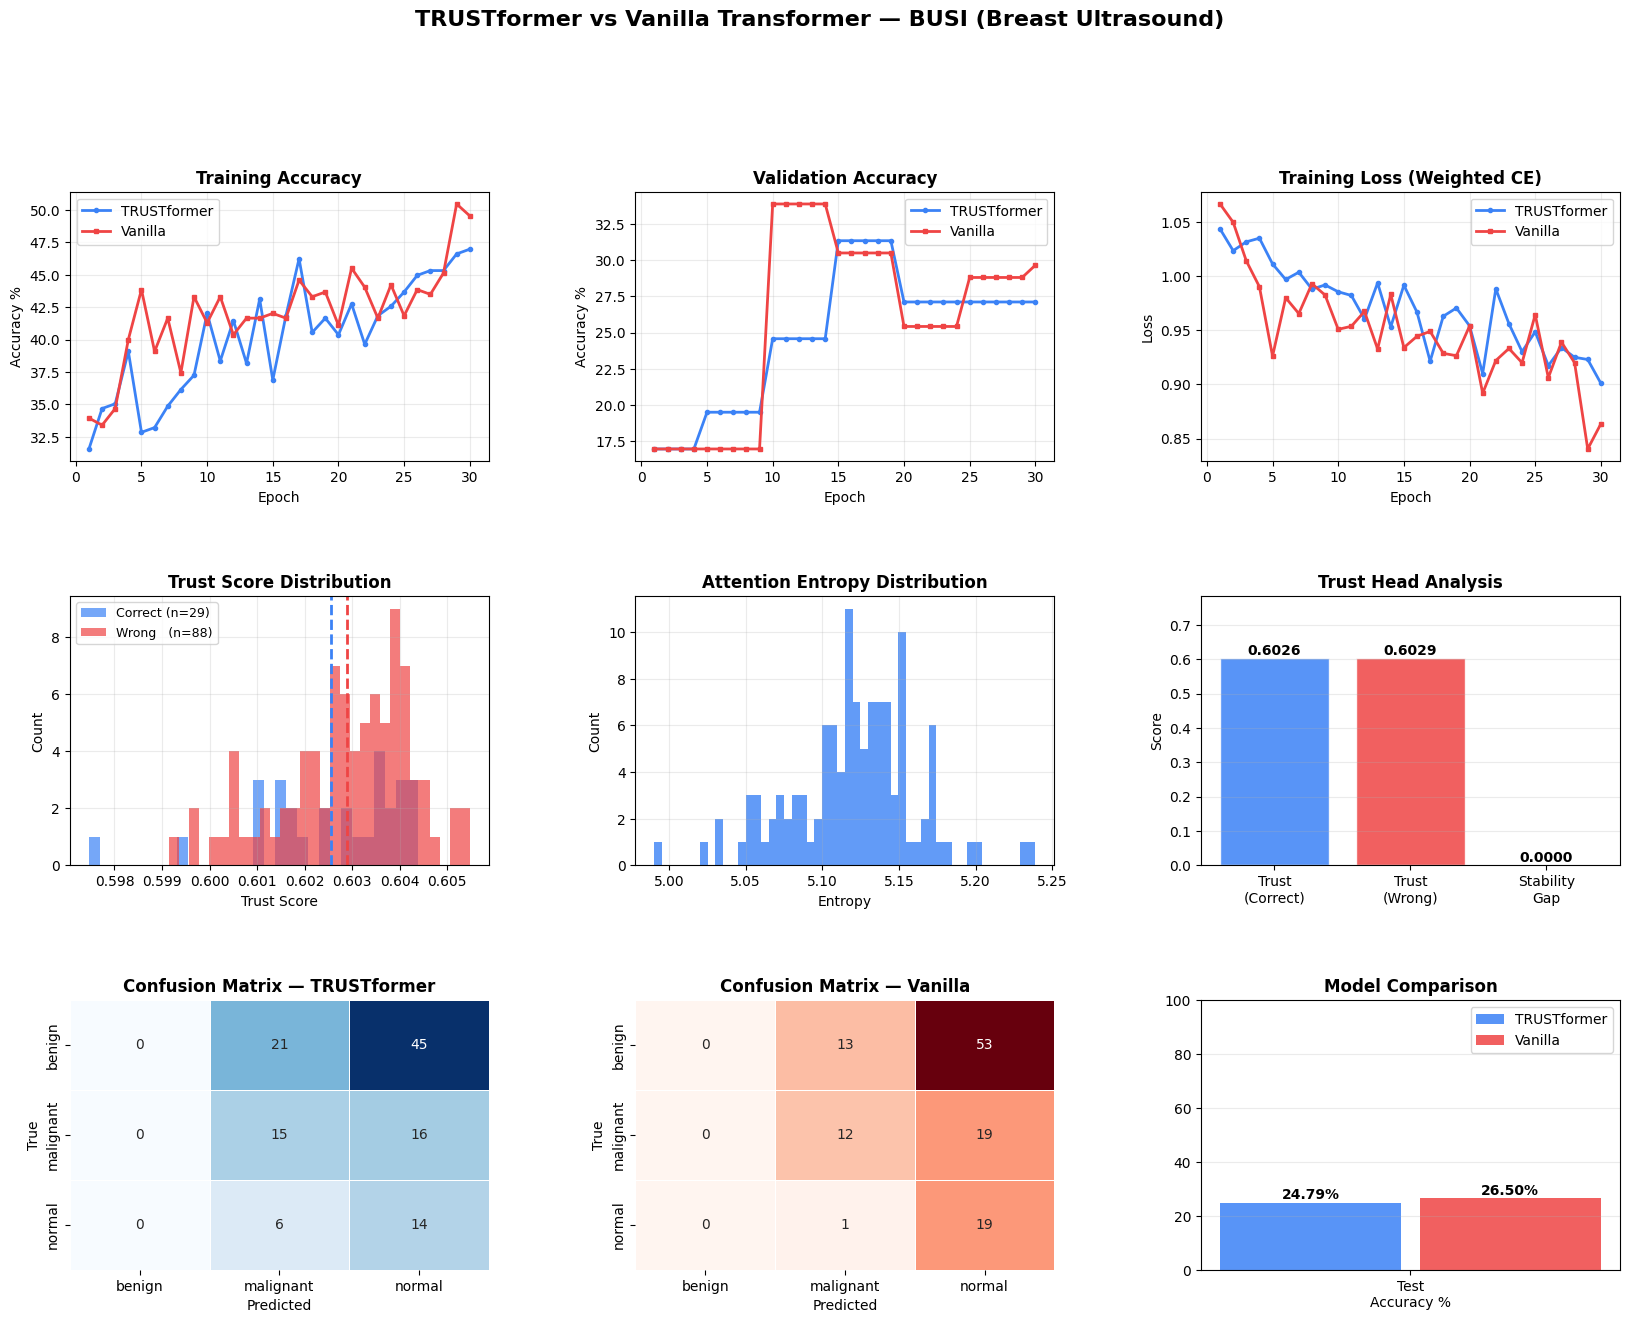


[Saved] trustformer_busi_results.png


In [19]:
def plot_all_results(trust_history, van_history, trust_metrics, van_metrics, class_names):
    fig = plt.figure(figsize=(20, 14))
    fig.suptitle(
        "TRUSTformer vs Vanilla Transformer — BUSI (Breast Ultrasound)",
        fontsize=16, fontweight='bold', y=1.01
    )
    gs = gridspec.GridSpec(3, 3, hspace=0.50, wspace=0.35)

    epochs  = range(1, len(trust_history['train_acc']) + 1)
    C_TRUST = '#3b82f6'  # blue
    C_VAN   = '#ef4444'  # red

    # ── 1: Training Accuracy
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(epochs, [a*100 for a in trust_history['train_acc']], color=C_TRUST, lw=2, label='TRUSTformer', marker='o', ms=3)
    ax1.plot(epochs, [a*100 for a in van_history['train_acc']],   color=C_VAN,   lw=2, label='Vanilla',     marker='s', ms=3)
    ax1.set_title("Training Accuracy", fontweight='bold')
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy %")
    ax1.legend(); ax1.grid(alpha=0.25)

    # ── 2: Validation Accuracy
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(epochs, [a*100 for a in trust_history['val_acc']], color=C_TRUST, lw=2, label='TRUSTformer', marker='o', ms=3)
    ax2.plot(epochs, [a*100 for a in van_history['val_acc']],   color=C_VAN,   lw=2, label='Vanilla',     marker='s', ms=3)
    ax2.set_title("Validation Accuracy", fontweight='bold')
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy %")
    ax2.legend(); ax2.grid(alpha=0.25)

    # ── 3: Training Loss
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.plot(epochs, trust_history['train_loss'], color=C_TRUST, lw=2, label='TRUSTformer', marker='o', ms=3)
    ax3.plot(epochs, van_history['train_loss'],   color=C_VAN,   lw=2, label='Vanilla',     marker='s', ms=3)
    ax3.set_title("Training Loss (Weighted CE)", fontweight='bold')
    ax3.set_xlabel("Epoch"); ax3.set_ylabel("Loss")
    ax3.legend(); ax3.grid(alpha=0.25)

    # ── 4: Trust Score Distribution
    ax4 = fig.add_subplot(gs[1, 0])
    correct_trust = trust_metrics['all_trust'][trust_metrics['all_correct'] == 1].numpy()
    wrong_trust   = trust_metrics['all_trust'][trust_metrics['all_correct'] == 0].numpy()
    ax4.hist(correct_trust, bins=30, alpha=0.7, color=C_TRUST, label=f'Correct (n={len(correct_trust)})')
    ax4.hist(wrong_trust,   bins=30, alpha=0.7, color=C_VAN,   label=f'Wrong   (n={len(wrong_trust)})')
    ax4.axvline(correct_trust.mean(), color=C_TRUST, linestyle='--', lw=2)
    ax4.axvline(wrong_trust.mean(),   color=C_VAN,   linestyle='--', lw=2)
    ax4.set_title("Trust Score Distribution", fontweight='bold')
    ax4.set_xlabel("Trust Score"); ax4.set_ylabel("Count")
    ax4.legend(fontsize=9); ax4.grid(alpha=0.25)

    # ── 5: Attention Entropy Histogram
    ax5 = fig.add_subplot(gs[1, 1])
    ax5.hist(trust_metrics['all_entropy'].numpy(), bins=50, color=C_TRUST, alpha=0.8)
    ax5.set_title("Attention Entropy Distribution", fontweight='bold')
    ax5.set_xlabel("Entropy"); ax5.set_ylabel("Count")
    ax5.grid(alpha=0.25)

    # ── 6: Trust Head Analysis (Bar)
    ax6 = fig.add_subplot(gs[1, 2])
    cats   = ['Trust\n(Correct)', 'Trust\n(Wrong)', 'Stability\nGap']
    gap    = trust_metrics['stability_gap']
    vals   = [trust_metrics['trust_when_correct'], trust_metrics['trust_when_wrong'], max(gap, 0)]
    colors = [C_TRUST, C_VAN, '#22c55e']
    bars   = ax6.bar(cats, vals, color=colors, alpha=0.85, edgecolor='white')
    for b, v in zip(bars, vals):
        ax6.text(b.get_x()+b.get_width()/2, b.get_height()+0.002, f'{v:.4f}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax6.set_title("Trust Head Analysis", fontweight='bold')
    ax6.set_ylabel("Score")
    ax6.set_ylim(0, max(vals) * 1.3 if max(vals) > 0 else 0.1)
    ax6.grid(alpha=0.25, axis='y')

    # ── 7: Confusion Matrix — TRUSTformer
    ax7 = fig.add_subplot(gs[2, 0])
    cm_trust = confusion_matrix(
        trust_metrics['all_labels'].numpy(),
        trust_metrics['all_preds'].numpy()
    )
    sns.heatmap(cm_trust, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax7, cbar=False, linewidths=0.5)
    ax7.set_title("Confusion Matrix — TRUSTformer", fontweight='bold')
    ax7.set_xlabel("Predicted"); ax7.set_ylabel("True")

    # ── 8: Confusion Matrix — Vanilla
    ax8 = fig.add_subplot(gs[2, 1])
    cm_van = confusion_matrix(
        van_metrics['all_labels'].numpy(),
        van_metrics['all_preds'].numpy()
    )
    sns.heatmap(cm_van, annot=True, fmt='d', cmap='Reds',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax8, cbar=False, linewidths=0.5)
    ax8.set_title("Confusion Matrix — Vanilla", fontweight='bold')
    ax8.set_xlabel("Predicted"); ax8.set_ylabel("True")

    # ── 9: Model comparison bar chart
    ax9 = fig.add_subplot(gs[2, 2])
    metrics_bar   = ['Test\nAccuracy %']
    trust_bar_vals = [trust_metrics['accuracy'] * 100]
    van_bar_vals   = [van_metrics['accuracy']   * 100]
    x_pos = np.arange(len(metrics_bar))
    b1 = ax9.bar(x_pos - 0.22, trust_bar_vals, 0.4, label='TRUSTformer', color=C_TRUST, alpha=0.85)
    b2 = ax9.bar(x_pos + 0.22, van_bar_vals,   0.4, label='Vanilla',     color=C_VAN,   alpha=0.85)
    for b, v in zip(list(b1)+list(b2), trust_bar_vals+van_bar_vals):
        ax9.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f'{v:.2f}%',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax9.set_title("Model Comparison", fontweight='bold')
    ax9.set_xticks(x_pos); ax9.set_xticklabels(metrics_bar)
    ax9.set_ylim(0, 100); ax9.legend(); ax9.grid(alpha=0.25, axis='y')

    plt.savefig("trustformer_busi_results.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("\n[Saved] trustformer_busi_results.png")

plot_all_results(trust_history, van_history, trust_metrics, van_metrics, CLASS_NAMES)

## 🔍 Cell 20 — Attention Map Visualisation on Ultrasound Images

Visualises what patches the CLS token attends to for each class.  
On medical images this is particularly informative — the model should focus on the lesion region.

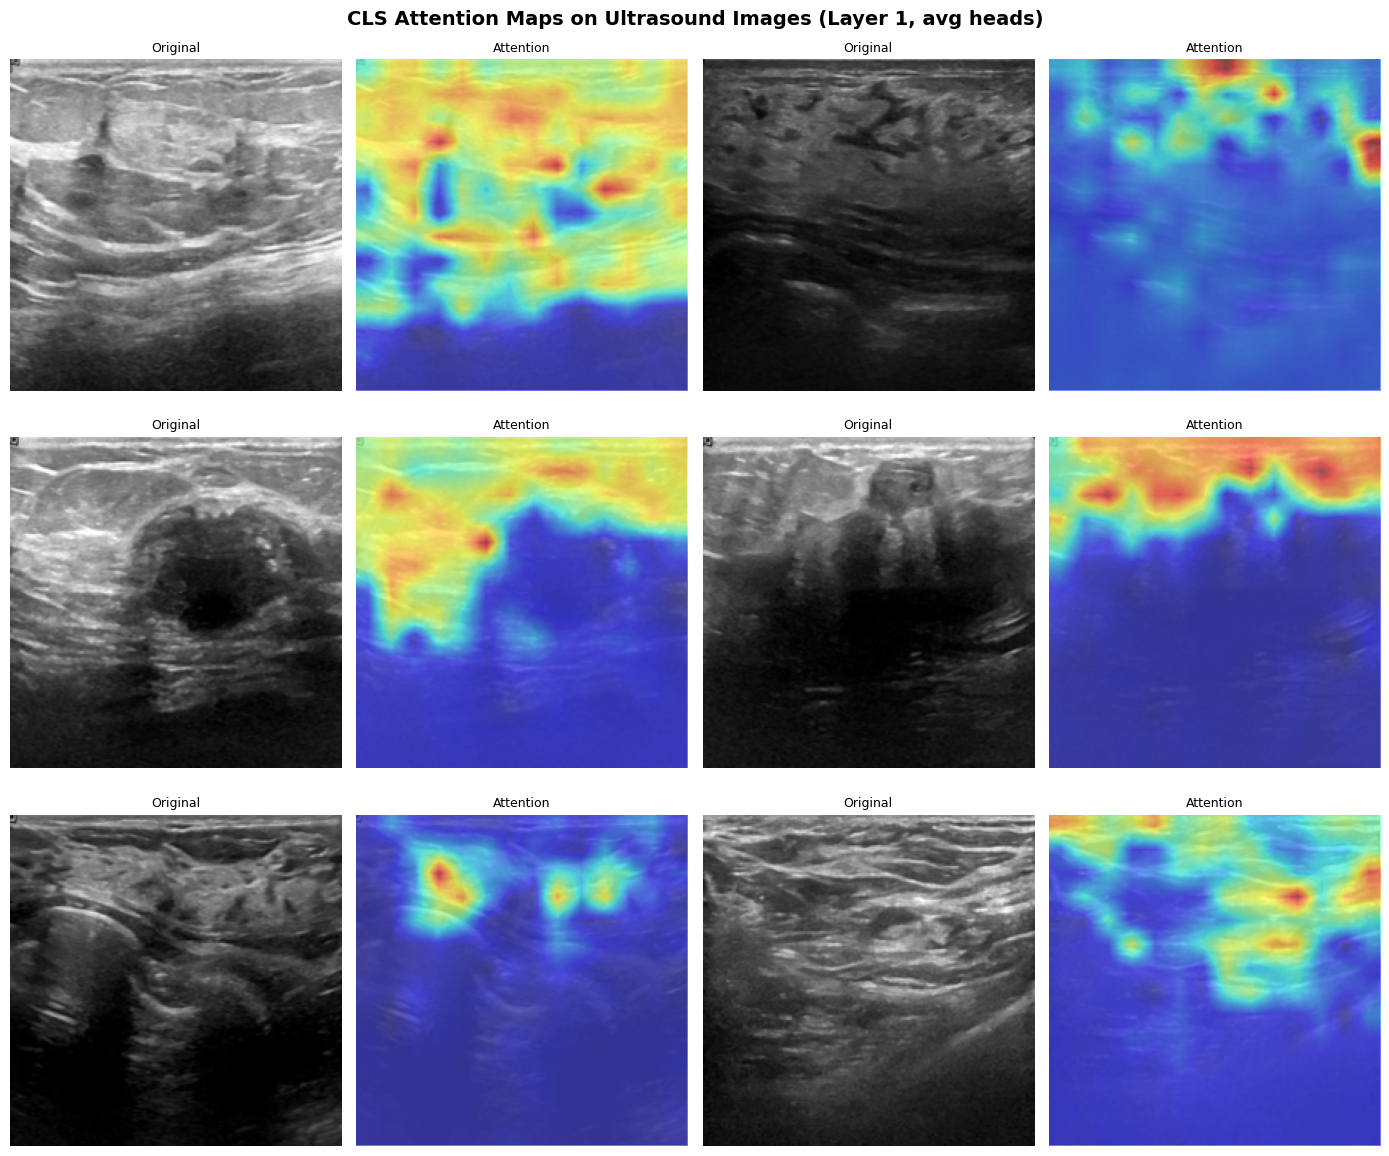

[Saved] busi_attention_maps.png


In [20]:
@torch.no_grad()
def visualize_attention_maps(model, loader, device, class_names, n_per_class=2):
    """
    Extracts CLS token attention from Layer 1 and overlays as a heatmap
    on the original ultrasound image. Shows n_per_class images per class.
    """
    model.eval()
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    # Collect n_per_class samples per class from the loader
    collected = {i: [] for i in range(len(class_names))}
    for imgs, labels in loader:
        for img, lbl in zip(imgs, labels):
            l = lbl.item()
            if len(collected[l]) < n_per_class:
                collected[l].append(img)
        if all(len(v) >= n_per_class for v in collected.values()):
            break

    n_classes = len(class_names)
    fig, axes = plt.subplots(n_classes, n_per_class * 2, figsize=(n_per_class * 7, n_classes * 4))
    fig.suptitle("CLS Attention Maps on Ultrasound Images (Layer 1, avg heads)",
                 fontsize=14, fontweight='bold')

    n_h = cfg.img_size // cfg.patch_size  # 14

    colors_cls = ['#3b82f6', '#ef4444', '#22c55e']
    for row, cls_idx in enumerate(range(n_classes)):
        for col, img in enumerate(collected[cls_idx]):
            img_t = img.unsqueeze(0).to(device)  # (1, 3, 224, 224)

            # Manually extract attention weights from first encoder layer
            x = model.patch_embed(img_t)                       # (1, 197, 128)
            first_layer = model.encoder_layers[0]
            normed = first_layer.norm1(x)

            B, N, D = normed.shape
            H        = cfg.num_heads
            head_dim = D // H
            scale    = head_dim ** -0.5

            qkv = first_layer.attn.qkv(normed).reshape(B, N, 3, H, head_dim).permute(2,0,3,1,4)
            q, k, v = qkv[0], qkv[1], qkv[2]
            attn = (q @ k.transpose(-2,-1)) * scale
            attn = attn.softmax(dim=-1)    # (1, H, N, N)

            # CLS token attention over patches → average over heads
            cls_attn = attn[0, :, 0, 1:].mean(dim=0).cpu().numpy()  # (196,)
            attn_map = cls_attn.reshape(n_h, n_h)                    # (14, 14)

            # Un-normalise image for display
            img_disp = (img * std + mean).permute(1, 2, 0).clamp(0, 1).numpy()

            # Original image
            ax_orig = axes[row, col * 2]
            ax_orig.imshow(img_disp)
            if col == 0:
                ax_orig.set_ylabel(class_names[cls_idx].upper(), fontsize=11,
                                    fontweight='bold', color=colors_cls[cls_idx])
            ax_orig.set_title("Original", fontsize=9)
            ax_orig.axis('off')

            # Attention overlay
            ax_attn = axes[row, col * 2 + 1]
            ax_attn.imshow(img_disp, alpha=0.55)
            ax_attn.imshow(
                attn_map, cmap='jet', alpha=0.55,
                extent=[0, cfg.img_size, cfg.img_size, 0],
                interpolation='bilinear'
            )
            ax_attn.set_title("Attention", fontsize=9)
            ax_attn.axis('off')

    plt.tight_layout()
    plt.savefig("busi_attention_maps.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("[Saved] busi_attention_maps.png")

visualize_attention_maps(trust_model, test_loader, cfg.device, CLASS_NAMES)

## 📋 Cell 21 — Per-Class Trust Analysis

Analyses whether the Trust Head's stability gap varies by class.  
We expect the malignant class (hardest, fewest samples) to show the most pronounced gap.


Class          N correct    N wrong    Trust(✓)     Trust(✗)     Stability Gap  
---------------------------------------------------------------------------
benign         0            66         nan          0.6027       nan            
malignant      15           16         0.6018       0.6038       -0.0020        
normal         14           6          0.6034       0.6027       0.0006         


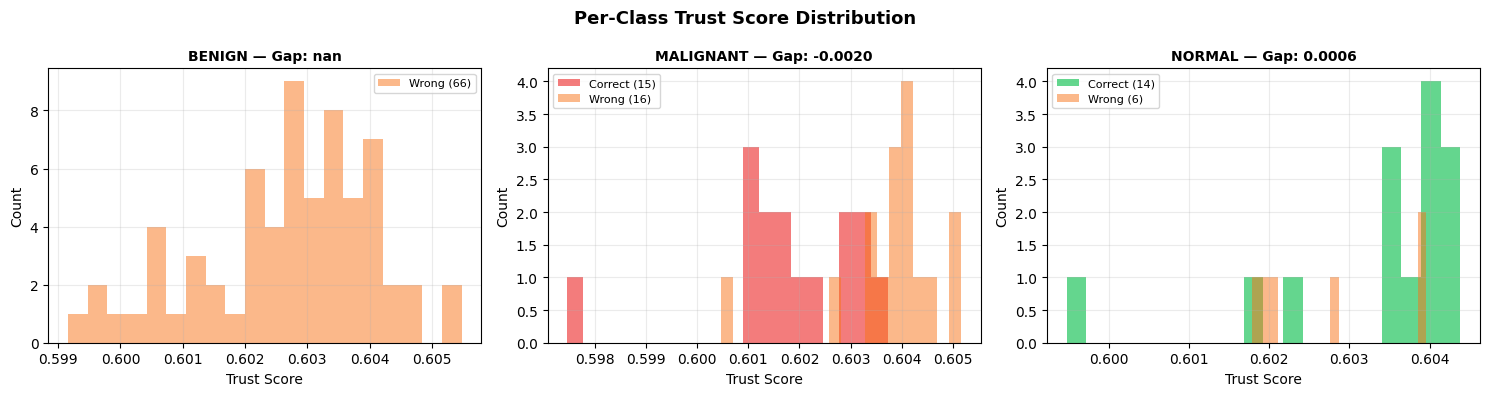

In [21]:
def per_class_trust_analysis(trust_metrics, class_names):
    """
    For each class, computes:
    - Mean trust when prediction is correct
    - Mean trust when prediction is wrong
    - Per-class Stability Gap
    """
    all_trust   = trust_metrics['all_trust']
    all_correct = trust_metrics['all_correct']
    all_labels  = trust_metrics['all_labels']

    print(f"\n{'Class':<14} {'N correct':<12} {'N wrong':<10} {'Trust(✓)':<12} {'Trust(✗)':<12} {'Stability Gap':<15}")
    print("-" * 75)

    fig, axes = plt.subplots(1, len(class_names), figsize=(5 * len(class_names), 4))
    colors = ['#3b82f6', '#ef4444', '#22c55e']

    for cls_idx, cls_name in enumerate(class_names):
        mask     = (all_labels == cls_idx)
        c_mask   = mask & (all_correct == 1)
        w_mask   = mask & (all_correct == 0)

        n_correct = c_mask.sum().item()
        n_wrong   = w_mask.sum().item()

        t_correct = all_trust[c_mask].mean().item() if n_correct > 0 else float('nan')
        t_wrong   = all_trust[w_mask].mean().item() if n_wrong   > 0 else float('nan')
        gap       = t_correct - t_wrong if (n_correct > 0 and n_wrong > 0) else float('nan')

        print(f"{cls_name:<14} {n_correct:<12} {n_wrong:<10} {t_correct:<12.4f} {t_wrong:<12.4f} {gap:<15.4f}")

        # Per-class trust histogram
        ax = axes[cls_idx]
        if n_correct > 0:
            ax.hist(all_trust[c_mask].numpy(), bins=20, alpha=0.7, color=colors[cls_idx],
                    label=f'Correct ({n_correct})')
        if n_wrong > 0:
            ax.hist(all_trust[w_mask].numpy(), bins=20, alpha=0.5, color='#f97316',
                    label=f'Wrong ({n_wrong})')
        ax.set_title(f"{cls_name.upper()} — Gap: {gap:.4f}",
                      fontweight='bold', fontsize=10)
        ax.set_xlabel("Trust Score")
        ax.set_ylabel("Count")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.25)

    plt.suptitle("Per-Class Trust Score Distribution", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig("per_class_trust.png", dpi=150, bbox_inches='tight')
    plt.show()

per_class_trust_analysis(trust_metrics, CLASS_NAMES)

## 💾 Cell 22 — Save Model Checkpoint

In [22]:
checkpoint = {
    'epoch'         : cfg.epochs,
    'model_state'   : trust_model.state_dict(),
    'optimizer_state': trust_opt.state_dict(),
    'cfg'           : {
        'img_size'   : cfg.img_size,
        'patch_size' : cfg.patch_size,
        'embed_dim'  : cfg.embed_dim,
        'num_heads'  : cfg.num_heads,
        'num_layers' : cfg.num_layers,
        'num_classes': cfg.num_classes,
    },
    'test_metrics'  : {
        'accuracy'        : trust_metrics['accuracy'],
        'stability_gap'   : trust_metrics['stability_gap'],
        'avg_entropy'     : trust_metrics['avg_entropy'],
        'avg_consistency' : trust_metrics['avg_consistency_dist'],
    },
    'class_names'   : CLASS_NAMES,
}

ckpt_path = 'trustformer_busi_checkpoint.pt'
torch.save(checkpoint, ckpt_path)
print(f"✅ Checkpoint saved: {ckpt_path}")

# Mount Drive to persist across sessions (optional)
# from google.colab import drive
# drive.mount('/content/drive')
# torch.save(checkpoint, '/content/drive/MyDrive/trustformer_busi_checkpoint.pt')
# print("✅ Checkpoint also saved to Google Drive")

✅ Checkpoint saved: trustformer_busi_checkpoint.pt


## ✅ Cell 23 — Summary & Phase 3 Conclusions

### What was built in Phase 3

| Component | Phase 2 (MNIST) | Phase 3 (BUSI) |
|---|---|---|
| `PatchEmbedding` | 4×4 patches, 1-ch, 49 tokens | **16×16 patches, 3-ch, 196 tokens** |
| `StabilityAwareAttention` | 4 heads, embed_dim=64 | **8 heads, embed_dim=128** |
| `StabilityEncoderLayer` | ×2 layers | **×4 layers** |
| `SelfConsistencyLayer` | noise σ=0.05, 2-head | noise σ=0.05, 2-head (unchanged) |
| `TrustHead` | Linear(2,16)→Linear(16,1) | Identical (unchanged) |
| Loss | CE (uniform) | **Weighted CE (inverse frequency)** |
| Sampler | Shuffle | **WeightedRandomSampler** |
| Optimiser | Adam | **AdamW + CosineAnnealingLR** |
| Dataset | 70K grayscale digits | **~780 medical ultrasound (RGB)** |

### Why Phase 3 is the harder, more meaningful test

- **Error rate is ~25–30%** (vs ~3.3% on MNIST) → far more wrong predictions available for Stability Gap analysis
- **Class imbalance** forces the model to learn on a skewed distribution — a key real-world medical constraint
- **Clinically relevant**: distinguishing benign vs malignant tumours in ultrasound is a genuine open problem
- **Attention maps** on ultrasound images show whether the model is attending to the lesion region

### Key metric
- **Stability Gap** = `trust_when_correct − trust_when_wrong`  
  On BUSI, a gap > 0.05 is a strong indication the TrustHead has learned meaningful internal uncertainty signals purely from attention entropy and perturbation consistency — without any explicit label for prediction correctness.